# Car Price Prediction — Exploratory Data Analysis

## Notebook 02: EDA and Data Quality

**Author:** Muhammad Waqas  
**Project:** Linear and Regularized Regression  

### Objective

The objective of this notebook is to explore data distributions, category frequencies, feature relationships, correlations, and potential outliers before preprocessing and model training.

### Research Focus

- Understand the distribution of car prices.
- Identify features associated with price variation.
- Examine whether numerical relationships appear linear or nonlinear.
- Detect unusual observations that may influence regression models.

## 1. Import Required Libraries

The libraries required for data handling, numerical operations, file-path management, and visualization are imported.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The raw car price dataset is loaded for exploratory data analysis. The original data file remains unchanged.

In [2]:
data_path = Path("../data/raw/car_price_prediction.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2500, 10)


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


## 3. Target Variable Analysis

### 3.1 Distribution of Car Prices

A histogram and density curve are used to examine the distribution, spread, and shape of the target variable.

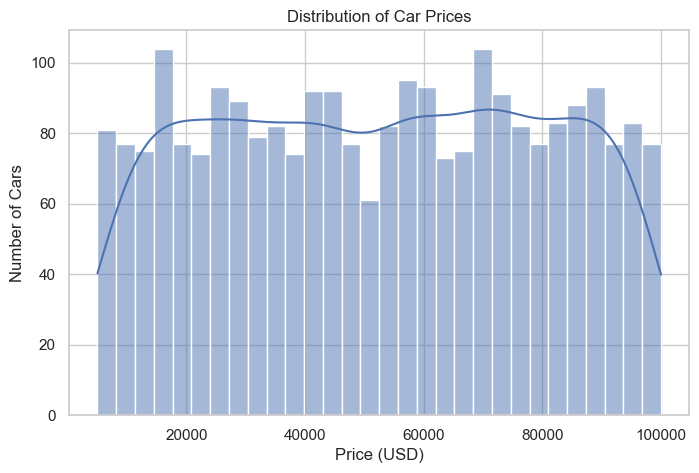

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Price", bins=30, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")
plt.show()

### Price Distribution Observation

Car prices are distributed broadly and approximately uniformly between USD 5,000 and USD 100,000. The distribution does not show strong positive or negative skewness, a dominant central peak, or clearly isolated extreme values.

Based only on this distribution, a logarithmic transformation of the target is not currently justified. However, the nearly uniform price distribution is unusual for real-world vehicle-market data. Feature–price relationships must therefore be examined carefully before judging the dataset’s suitability for meaningful research conclusions.

### 3.2 Boxplot of Car Prices

A boxplot is used to examine the target variable’s median, interquartile range, overall spread, and potential outliers.

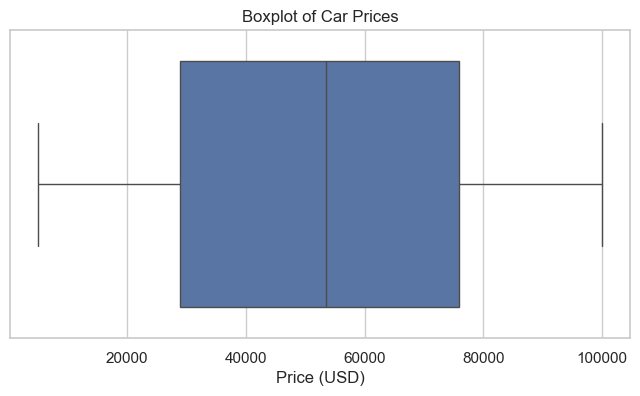

In [4]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Price")

plt.title("Boxplot of Car Prices")
plt.xlabel("Price (USD)")
plt.show()

### Price Boxplot Observation

The median car price is approximately USD 53,485. The first and third quartiles are approximately USD 28,909 and USD 75,839, respectively.

No observations appear beyond the boxplot whiskers. Therefore, the standard IQR rule does not identify potential outliers in the target variable. The relatively balanced box and whiskers also support the earlier observation that the price distribution is broadly uniform and not strongly skewed.

No target values will be removed, capped, or transformed at this stage.

## 4. Numerical Feature Analysis

### 4.1 Distribution of Vehicle Year

The distribution of vehicle manufacturing years is examined to understand how observations are spread across older and newer vehicles.

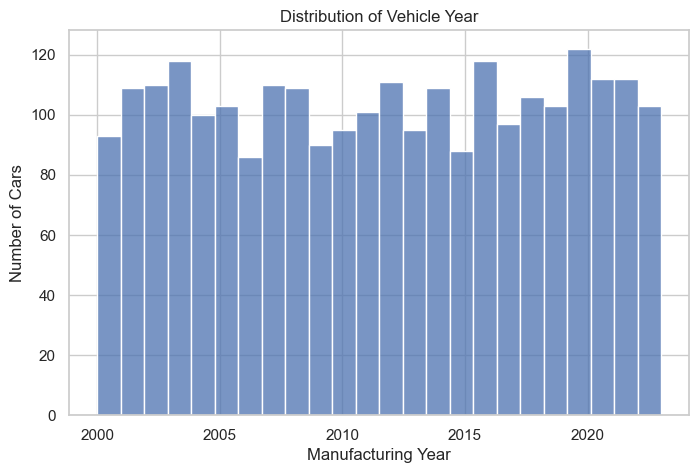

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Year", bins=24)

plt.title("Distribution of Vehicle Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")
plt.show()

### Vehicle Year Distribution Observation

Vehicle years are distributed relatively evenly between 2000 and 2023. No single year or time period strongly dominates the dataset, and no major gaps are visible.

The dataset therefore provides coverage of both older and newer vehicles. However, this graph only describes the frequency of vehicle years; it does not establish how manufacturing year is related to car price.

The unusually even distribution also supports the need to verify whether the dataset represents natural market data or artificially balanced observations.

### 4.2 Distribution of Engine Size

The distribution of engine size is examined to understand its range, concentration, and overall shape.

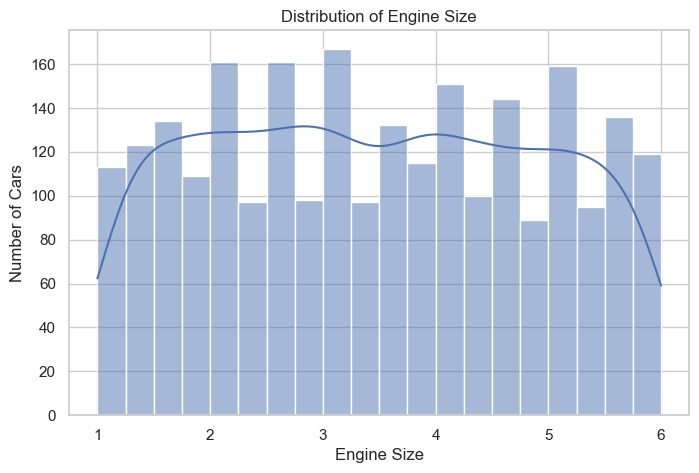

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Engine Size", bins=20, kde=True)

plt.title("Distribution of Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Number of Cars")
plt.show()

### Engine Size Distribution Observation

Engine size values range from approximately 1.0 to 6.0 and are broadly distributed across the complete range. The distribution does not show strong skewness, a dominant peak, major gaps, or obvious extreme values.

The relatively even distribution provides representation of both small and large engines. However, this graph does not determine whether engine size has a meaningful relationship with car price.

The measurement unit is not included in the column name and should be verified from the original dataset documentation before formal research reporting.

### 4.3 Distribution of Mileage

The mileage distribution is examined to understand its range, spread, skewness, and possible unusual values.

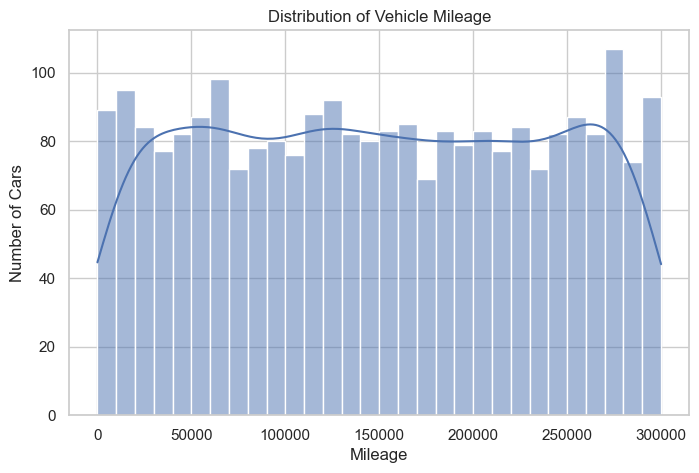

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Mileage", bins=30, kde=True)

plt.title("Distribution of Vehicle Mileage")
plt.xlabel("Mileage")
plt.ylabel("Number of Cars")
plt.show()

### Mileage Distribution Observation

Mileage values cover a wide range from approximately 15 to 300,000 and are distributed broadly across the complete range. The distribution does not show strong skewness, a dominant concentration, major gaps, or visually isolated extreme groups.

The very low minimum mileage may represent a nearly new vehicle, but it should be checked against vehicle year and condition. The mileage unit must also be confirmed from the original dataset documentation.

The unusually even distribution further supports the need to examine whether mileage has realistic relationships with vehicle year, condition, and price.

### 4.4 Boxplots of Numerical Input Features

Separate boxplots are used to examine the spread and potential outliers of vehicle year, engine size, and mileage.

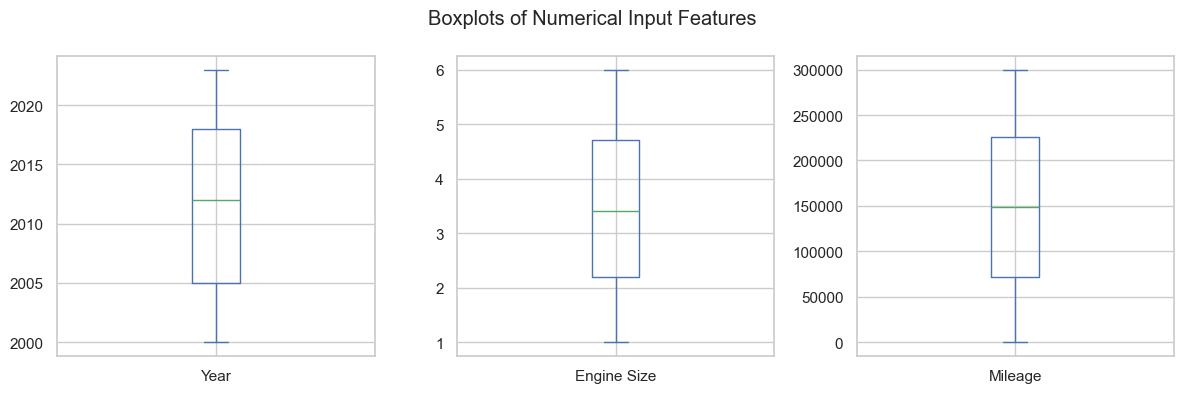

In [8]:
df[["Year", "Engine Size", "Mileage"]].plot(
    kind="box",
    subplots=True,
    layout=(1, 3),
    figsize=(12, 4),
    sharey=False
)

plt.suptitle("Boxplots of Numerical Input Features")
plt.tight_layout()
plt.show()

### Numerical Outlier Observation

The boxplots do not show observations beyond the whiskers for vehicle year, engine size, or mileage. Therefore, the standard IQR rule does not identify potential univariate outliers in these numerical input features.

No numerical observations will be removed or capped at this stage. However, the absence of univariate outliers does not guarantee that every combination of values is realistic. Relationships between year, mileage, condition, and price must still be examined for possible multivariate inconsistencies.

Each boxplot uses a different measurement scale, so their numerical spreads should not be compared directly.

## 5. Categorical Feature Analysis

### 5.1 Frequency of Car Brands

The number of observations for each car brand is examined to identify category representation and possible imbalance.

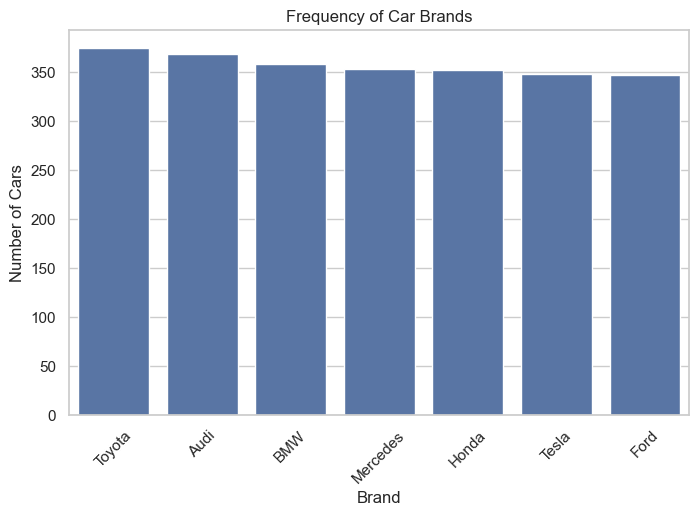

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Brand",
    order=df["Brand"].value_counts().index
)

plt.title("Frequency of Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.show()

### Brand Frequency Observation

All seven car brands are represented in similar numbers, with approximately 345 to 375 observations per brand. Toyota has the highest frequency, but the difference between brands is small.

No brand appears severely underrepresented or rare. This balanced representation allows the regression models to learn from a reasonable number of observations for every brand.

However, the unusually balanced frequencies may indicate controlled or synthetic sampling. Category frequency alone does not determine whether a brand is associated with higher or lower prices.

### 5.2 Frequency of Fuel Types

The number of vehicles in each fuel-type category is examined to identify category representation and possible imbalance.

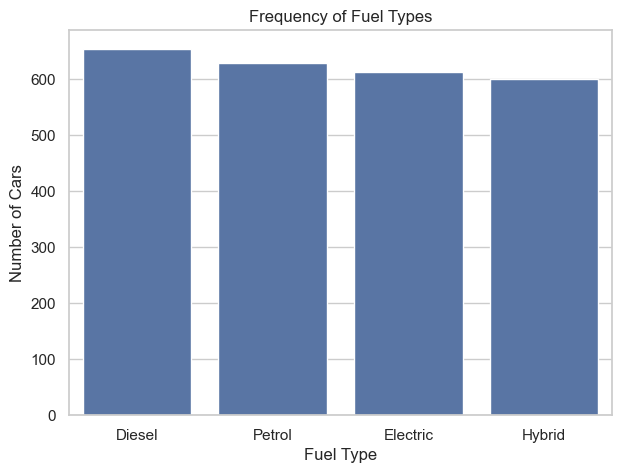

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Fuel Type",
    order=df["Fuel Type"].value_counts().index
)

plt.title("Frequency of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

### Fuel Type Frequency Observation

Diesel, Petrol, Electric, and Hybrid vehicles are represented in similar numbers. Diesel has the highest frequency and Hybrid has the lowest, but the difference is relatively small.

No fuel type is rare or severely underrepresented. This provides sufficient observations for each category during encoding and model training.

However, the highly balanced representation may reflect controlled or synthetic sampling rather than the natural composition of a specific vehicle market. Therefore, generalization to a real market should not be assumed without geographic and temporal context.

### 5.3 Frequency of Transmission and Vehicle Condition

Transmission and vehicle-condition categories are examined to identify their representation and possible imbalance.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Transmission", ax=axes[0])
axes[0].set_title("Frequency of Transmission Types")

sns.countplot(data=df, x="Condition", ax=axes[1])
axes[1].set_title("Frequency of Vehicle Conditions")

plt.tight_layout()
plt.show()

### Transmission and Condition Frequency Observation

Manual and Automatic vehicles are represented in similar numbers, although Manual vehicles are slightly more frequent. No transmission category is severely underrepresented.

New, Used, and Like New vehicles are also represented in similar numbers, with Used vehicles having the highest frequency. No vehicle-condition category is rare.

These balanced categories provide sufficient observations for model training. However, vehicle condition should be checked against mileage and manufacturing year to identify potentially unrealistic combinations. The highly balanced category frequencies may also reflect controlled or synthetic sampling.

### 5.4 Frequency of Car Models

The number of observations for each car model is examined to identify high-cardinality categories, rare models, and representation imbalance.

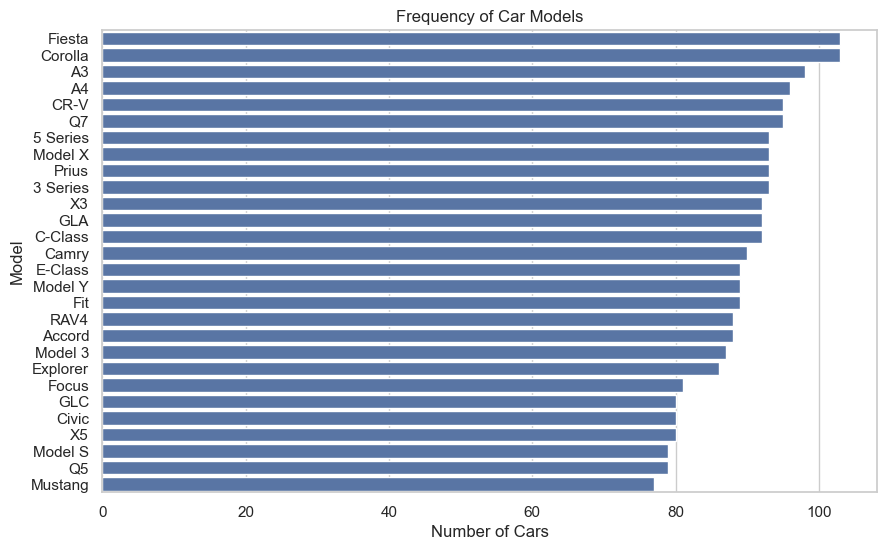

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Model",
    order=df["Model"].value_counts().index
)

plt.title("Frequency of Car Models")
plt.xlabel("Number of Cars")
plt.ylabel("Model")
plt.show()

### Model Frequency Observation

The dataset contains 28 car models, with approximately 77 to 103 observations per model. Fiesta and Corolla have the highest frequencies, while Mustang has the lowest frequency.

No model is severely underrepresented or rare. However, `Model` has the highest categorical cardinality and will create the largest number of encoded features during preprocessing.

Car models are logically associated with particular brands. Therefore, the relationship between `Brand` and `Model` must be checked for redundant information and possible multicollinearity. The unusually balanced model frequencies may also reflect controlled or synthetic sampling.

## 6. Data Consistency Checks

### 6.1 Brand–Model Relationship

The relationship between car models and brands is checked to determine whether each model belongs to one brand and whether both variables may contain overlapping information.

In [17]:
brands_per_model = df.groupby("Model")["Brand"].nunique()

brands_per_model.value_counts()

Brand
1    28
Name: count, dtype: int64

### Brand–Model Relationship Observation

All 28 car models are associated with exactly one brand. This confirms that the Brand–Model mapping is logically consistent.

However, `Model` already contains information about `Brand`. Including both variables after one-hot encoding may introduce redundant features and structural multicollinearity, making coefficient interpretation less reliable.

Both columns will remain unchanged in the raw dataset. Their final treatment will be decided during preprocessing and model comparison rather than through premature deletion.

### 6.2 Condition–Mileage Consistency

Mileage distributions are compared across vehicle-condition categories to determine whether the values follow a logically meaningful pattern.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Mileage",
    order=["New", "Like New", "Used"]
)

plt.title("Mileage Distribution by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Mileage")
plt.show()

### Condition–Mileage Consistency Observation

The mileage distributions for New, Like New, and Used vehicles overlap almost completely. All three categories cover approximately the same mileage range, and their median values are also similar.

The expected logical pattern—lower mileage for New vehicles and higher mileage for Used vehicles—is not visible. The presence of very high-mileage observations in the New category raises a data-validity concern.

This may indicate that vehicle condition was assigned independently of mileage, that the variable definition is ambiguous, or that the dataset was synthetically generated. No observations will be removed without confirming the original variable definition, but this issue must be reported as a dataset limitation.

### 6.3 Condition–Year Consistency

Vehicle-year distributions are compared across condition categories to determine whether newer and older vehicles follow a logically meaningful condition pattern.

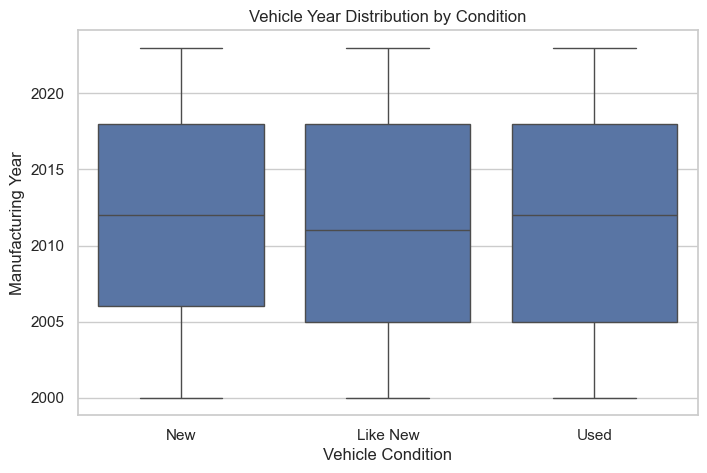

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Year",
    order=["New", "Like New", "Used"]
)

plt.title("Vehicle Year Distribution by Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Manufacturing Year")
plt.show()

### Condition–Year Consistency Observation

Vehicle-year distributions are nearly identical across New, Like New, and Used condition categories. Each condition contains vehicles from approximately 2000 to 2023, while their medians and interquartile ranges are also very similar.

The expected tendency for newer vehicles to appear more frequently in better-condition categories is not visible. Combined with the earlier Condition–Mileage result, this suggests that `Condition` may have been assigned independently of vehicle age and usage.

Unless `New` is explicitly defined as restored physical condition rather than vehicle age or ownership status, this variable has limited real-world interpretability. The issue will be retained as a major dataset limitation rather than corrected through unsupported assumptions.

### 6.4 Year–Mileage Consistency

A scatterplot is used to examine whether vehicle mileage decreases as the manufacturing year becomes more recent.


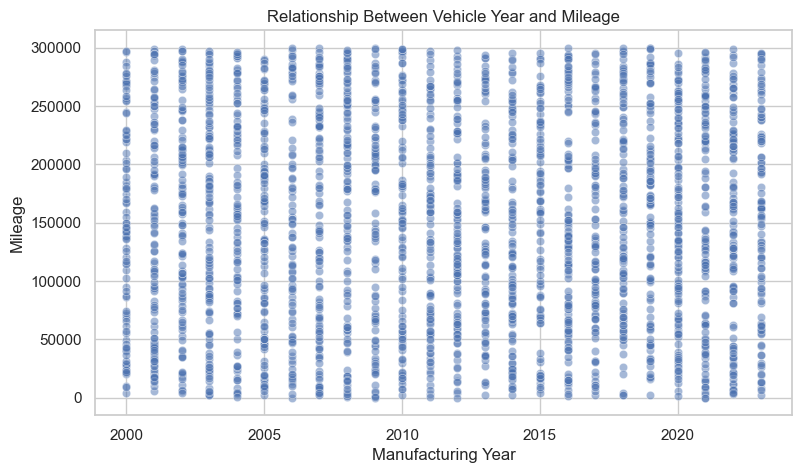

In [20]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Mileage",
    alpha=0.5
)

plt.title("Relationship Between Vehicle Year and Mileage")
plt.xlabel("Manufacturing Year")
plt.ylabel("Mileage")
plt.show()

### Year–Mileage Consistency Observation

The scatterplot does not show the expected negative relationship between manufacturing year and mileage. Vehicles from almost every year cover the complete mileage range, from nearly zero to approximately 300,000.

The vertical bands occur because manufacturing year is recorded as a discrete integer and do not represent a plotting error. The important concern is the absence of a meaningful downward trend for newer vehicles.

Combined with the Condition–Mileage and Condition–Year findings, this pattern strongly suggests that important variables may have been generated independently or randomly. The dataset may remain useful for learning a Machine Learning workflow, but it should not be used for real-world market conclusions or publishable research without stronger validation.

## 7. Feature–Target Relationship Analysis

### 7.1 Numerical Correlation Matrix

Pearson correlation is calculated to measure the direction and strength of linear relationships among the numerical input features and car price.

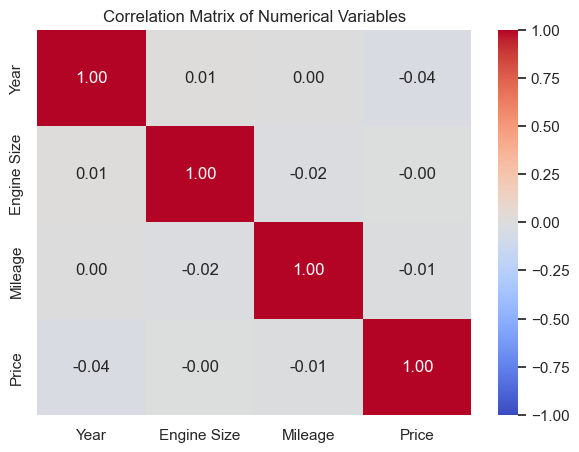

In [21]:
numerical_data = df[["Year", "Engine Size", "Mileage", "Price"]]

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Numerical Correlation Observation

All numerical correlations are extremely close to zero. Vehicle Year has a correlation of approximately -0.04 with Price, Engine Size has approximately 0.00 correlation with Price, and Mileage has approximately -0.01 correlation with Price.

The expected domain relationships—higher prices for newer vehicles and lower prices for high-mileage vehicles—are not visible. The numerical input features are also nearly uncorrelated with one another.

Pearson correlation only measures linear relationships and cannot independently rule out nonlinear patterns. However, when combined with the uniform distributions and failed Year–Mileage, Condition–Mileage, and Condition–Year consistency checks, the evidence strongly suggests independent or random variable generation.

Linear and regularized regression models are unlikely to learn meaningful price patterns from these numerical features. This represents a major limitation for real-world interpretation and publishable research.

## 8. Dataset Suitability Decision

The exploratory data analysis indicates that this dataset is likely synthetic.

### Main Evidence

- Price, Year, Engine Size, and Mileage are approximately uniformly distributed.
- Numerical features have almost zero correlation with Price.
- Mileage and Year distributions are nearly identical across vehicle conditions.
- Some vehicles marked as New have very high mileage and old manufacturing years.
- Categorical classes are unusually balanced.

### Final Decision

This dataset is suitable for learning data analysis and machine learning
workflow development. However, it is not suitable for making real-world
automobile market conclusions without verification of its original source
and data-generation method.

Therefore, the dataset will be retained as a data-quality audit example.
A verified real-world dataset will be selected for the final regression
modeling and research experiments.